# Лабораторная работа №2: Проведение исследований с логистической и линейной регрессией

## Цель работы
Исследование алгоритмов логистической регрессии (для классификации) и линейной регрессии (для регрессии) на реальных данных. Работа включает создание бейзлайна с использованием библиотеки sklearn, его улучшение и самостоятельную имплементацию алгоритмов.

## Используемые датасеты
- **Классификация:** "Human Activity Recognition with Smartphones" — данные с акселерометра и гироскопа смартфона для определения 6 видов активности человека.
- **Регрессия:** "CO2 Emission by Vehicles" — характеристики автомобилей и уровень выбросов CO₂.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [24]:
# Загрузка данных для классификации
train_class = pd.read_csv('datasets/HUMAN_ACTIVITY/train.csv')
test_class = pd.read_csv('datasets/HUMAN_ACTIVITY/test.csv')

# Загрузка данных для регрессии
data_reg = pd.read_csv('datasets/CO2/CO2_dataset.csv')

print("Данные классификации загружены:")
print(f"  Train: {train_class.shape}, Test: {test_class.shape}")
print(f"\nДанные регрессии загружены: {data_reg.shape}")

Данные классификации загружены:
  Train: (7352, 563), Test: (2947, 563)

Данные регрессии загружены: (7385, 12)


## Предварительная обработка данных
Первичный анализ данных был проведен в первой ЛР, поэтому здесь сразу переходим к подготовке данных

### Для классификации:
1. Разделение на признаки и целевую переменную
2. Кодирование категориальной целевой переменной (меток активности) в числовой формат
3. Масштабирование признаков

### Для регрессии:
1. Выбор числовых признаков и целевой переменной
2. Масштабирование признаков
3. Разделение на тренировочную и тестовую выборки

In [25]:
# Подготовка данных для классификации
X_train_class = train_class.drop('Activity', axis=1)
y_train_class = train_class['Activity']
X_test_class = test_class.drop('Activity', axis=1)
y_test_class = test_class['Activity']

# Кодирование меток классов
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_class)
y_test_encoded = le.transform(y_test_class)

# Масштабирование признаков
scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

# Подготовка данных для регрессии
numeric_cols = data_reg.select_dtypes(include=[np.number]).columns
X_reg = data_reg[numeric_cols].drop('CO2 Emissions(g/km)', axis=1)
y_reg = data_reg['CO2 Emissions(g/km)']

# Разделение на train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Масштабирование признаков
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("Данные успешно подготовлены:")
print(f"Классификация: X_train_scaled {X_train_class_scaled.shape}, y_train {y_train_encoded.shape}")
print(f"Регрессия: X_train_scaled {X_train_reg_scaled.shape}, y_train {y_train_reg.shape}")

Данные успешно подготовлены:
Классификация: X_train_scaled (7352, 562), y_train (7352,)
Регрессия: X_train_scaled (5908, 6), y_train (5908,)


## Функции для вычисления метрик качества

Как обсуждалось в лекции 5, для задач классификации используем Accuracy, Precision, Recall, F1-Score и ROC-AUC. Для регрессии используем MSE, MAE и R².

In [26]:
# Функции для вычисления метрик
def classification_metrics(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
            metrics['ROC-AUC'] = auc
        except:
            metrics['ROC-AUC'] = None
    return metrics

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'MAE': mae, 'R2': r2}

## Бейзлайн: классификация с использованием LogisticRegression из sklearn

In [27]:
# Инициализация и обучение модели логистической регрессии
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_class_scaled, y_train_encoded)

# Прогнозы
y_pred_log_reg = log_reg.predict(X_test_class_scaled)
y_prob_log_reg = log_reg.predict_proba(X_test_class_scaled)

# Оценка метрик
metrics_log_reg = classification_metrics(y_test_encoded, y_pred_log_reg, y_prob_log_reg)
print("Метрики классификации (логистическая регрессия, бейзлайн):")
for key, value in metrics_log_reg.items():
    print(f"{key}: {value:.4f}")

Метрики классификации (логистическая регрессия, бейзлайн):
Accuracy: 0.9525
Precision: 0.9565
Recall: 0.9512
F1-Score: 0.9526
ROC-AUC: 0.9973


## Бейзлайн: регрессия с использованием LinearRegression из sklearn

In [ ]:
# Инициализация и обучение модели линейной регрессии
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)

# Прогнозы
y_pred_lin_reg = lin_reg.predict(X_test_reg_scaled)

# Оценка метрик
metrics_lin_reg = regression_metrics(y_test_reg, y_pred_lin_reg)
print("Метрики регрессии (линейная регрессия, бейзлайн):")
for key, value in metrics_lin_reg.items():
    print(f"{key}: {value:.4f}")

print(f"\nЧисло коэффициентов модели: {len(lin_reg.coef_)}")
print(f"Свободный член (intercept): {lin_reg.intercept_:.4f}")

Метрики регрессии (линейная регрессия, бейзлайн):
MSE: 337.4609
MAE: 11.5307
R2: 0.9019

Число коэффициентов модели: 6
Свободный член (intercept): 250.9396


## Улучшение бейзлайна: гипотезы

Для логистической регрессии важными гиперпараметрами являются:
1. Сила регуляризации (параметр C)
2. Тип регуляризации (L1, L2, ElasticNet)
3. Максимальное число итераций

Для линейной регрессии можно рассмотреть:
1. Регуляризацию (Ridge, Lasso, ElasticNet)
2. Подбор гиперпараметров регуляризации

Используем GridSearchCV для подбора оптимальных гиперпараметров.

In [29]:
# Подбор гиперпараметров для логистической регрессии
param_grid_log = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_log = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), 
                        param_grid_log, cv=5, scoring='accuracy', n_jobs=-1)
grid_log.fit(X_train_class_scaled, y_train_encoded)

print("Лучшие параметры для логистической регрессии:", grid_log.best_params_)
print("Лучшая accuracy на кросс-валидации:", grid_log.best_score_)

# Подбор гиперпараметров для различных видов регуляризованной линейной регрессии
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# 1. Ridge регрессия (L2 регуляризация)
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'fit_intercept': [True, False]
}

grid_ridge = GridSearchCV(Ridge(max_iter=10000), param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_ridge.fit(X_train_reg_scaled, y_train_reg)
print("\n1. Ridge регрессия (L2 регуляризация):")
print("   Лучшие параметры:", grid_ridge.best_params_)
print("   Лучший MSE на кросс-валидации:", -grid_ridge.best_score_)

# 2. Lasso регрессия (L1 регуляризация)
param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'fit_intercept': [True, False]
}

grid_lasso = GridSearchCV(Lasso(max_iter=10000), param_grid_lasso, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_lasso.fit(X_train_reg_scaled, y_train_reg)
print("\n2. Lasso регрессия (L1 регуляризация):")
print("   Лучшие параметры:", grid_lasso.best_params_)
print("   Лучший MSE на кросс-валидации:", -grid_lasso.best_score_)

# 3. ElasticNet регрессия (комбинированная L1+L2 регуляризация)
param_grid_elastic = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'fit_intercept': [True, False]
}

grid_elastic = GridSearchCV(ElasticNet(max_iter=10000), param_grid_elastic, cv=5, 
                            scoring='neg_mean_squared_error', n_jobs=-1)
grid_elastic.fit(X_train_reg_scaled, y_train_reg)
print("\n3. ElasticNet регрессия (L1+L2 регуляризация):")
print("   Лучшие параметры:", grid_elastic.best_params_)
print("   Лучший MSE на кросс-валидации:", -grid_elastic.best_score_)

# Выбор лучшей модели регрессии на основе MSE
models_reg = {
    'Ridge': grid_ridge,
    'Lasso': grid_lasso, 
    'ElasticNet': grid_elastic
}

best_model_name = min(models_reg.keys(), key=lambda x: -models_reg[x].best_score_)
best_model = models_reg[best_model_name].best_estimator_

print(f"\nЛучшая модель регрессии: {best_model_name}")
print(f"Лучший MSE на кросс-валидации: {-models_reg[best_model_name].best_score_:.4f}")

Лучшие параметры для логистической регрессии: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Лучшая accuracy на кросс-валидации: 0.9416560533118753

1. Ridge регрессия (L2 регуляризация):
   Лучшие параметры: {'alpha': 10, 'fit_intercept': True}
   Лучший MSE на кросс-валидации: 328.6537225829331

2. Lasso регрессия (L1 регуляризация):
   Лучшие параметры: {'alpha': 0.01, 'fit_intercept': True}
   Лучший MSE на кросс-валидации: 328.6869096191152

3. ElasticNet регрессия (L1+L2 регуляризация):
   Лучшие параметры: {'alpha': 0.01, 'fit_intercept': True, 'l1_ratio': 0.7}
   Лучший MSE на кросс-валидации: 328.6529384830146

Лучшая модель регрессии: ElasticNet
Лучший MSE на кросс-валидации: 328.6529


## Формирование улучшенного бейзлайна

In [30]:
# Улучшенная модель логистической регрессии
best_log_reg = grid_log.best_estimator_
y_pred_log_improved = best_log_reg.predict(X_test_class_scaled)
y_prob_log_improved = best_log_reg.predict_proba(X_test_class_scaled)

metrics_log_improved = classification_metrics(y_test_encoded, y_pred_log_improved, y_prob_log_improved)
print("Метрики классификации (улучшенная логистическая регрессия):")
for key, value in metrics_log_improved.items():
    print(f"{key}: {value:.4f}")

# Улучшенная модель линейной регрессии (выбранная по результатам GridSearchCV)
best_lin_reg = best_model  # Используем лучшую модель, определенную выше
y_pred_lin_improved = best_lin_reg.predict(X_test_reg_scaled)

metrics_lin_improved = regression_metrics(y_test_reg, y_pred_lin_improved)
print(f"Метрики регрессии (улучшенная {best_model_name} регрессия):")
for key, value in metrics_lin_improved.items():
    print(f"{key}: {value:.4f}")

Метрики классификации (улучшенная логистическая регрессия):
Accuracy: 0.9583
Precision: 0.9615
Recall: 0.9577
F1-Score: 0.9585
ROC-AUC: 0.9955
Метрики регрессии (улучшенная ElasticNet регрессия):
MSE: 337.4605
MAE: 11.5233
R2: 0.9019


## Сравнение с исходным бейзлайном

In [31]:
print("Сравнение классификации (логистическая регрессия):")
print("Метрика | Исходный | Улучшенный")
for key in metrics_log_reg.keys():
    if key in metrics_log_improved:
        print(f"{key:12} | {metrics_log_reg[key]:.4f} | {metrics_log_improved[key]:.4f}")

print(f"\nСравнение регрессии (линейная регрессия):")
print(f"Метрика | Исходный | Улучшенный ({best_model_name})")
for key in metrics_lin_reg.keys():
    print(f"{key:12} | {metrics_lin_reg[key]:.4f} | {metrics_lin_improved[key]:.4f}")

Сравнение классификации (логистическая регрессия):
Метрика | Исходный | Улучшенный
Accuracy     | 0.9525 | 0.9583
Precision    | 0.9565 | 0.9615
Recall       | 0.9512 | 0.9577
F1-Score     | 0.9526 | 0.9585
ROC-AUC      | 0.9973 | 0.9955

Сравнение регрессии (линейная регрессия):
Метрика | Исходный | Улучшенный (ElasticNet)
MSE          | 337.4609 | 337.4605
MAE          | 11.5307 | 11.5233
R2           | 0.9019 | 0.9019


## Самостоятельная реализация логистической регрессии

Реализуем алгоритм логистической регрессии для многоклассовой классификации с использованием метода one-vs-rest (OvR).

### Краткая идея
Градиентный спуск был использован для минимизации функции потерь (кросс-энтропии) в каждом бинарном классификаторе. Для решения многоклассовой задачи применялся подход one-vs-rest: для каждого класса обучается отдельный бинарный классификатор, отличающий данный класс от всех остальных. На этапе предсказания для каждого примера вычисляются вероятности от каждого бинарного классификатора и затем производится нормализация по строке, чтобы получить взаимосогласованные оценки принадлежности к классам.

### Модель и активация
Модель для каждого бинарного классификатора задаётся линейной функцией
$z = X w + b,$

а выходная вероятность вычисляется через сигмоид:
$ \sigma(z) = \frac{1}{1 + e^{-z}}.$

В реализации была добавлена защита от переполнения при вычислении экспоненты: аргумент функции экспоненты был ограничен (например, `np.clip(z, -250, 250)`), чтобы избежать `inf`/`nan`.

### Функция потерь
Для одного бинарного классификатора использована лог-потеря (log-loss / бинарная кросс-энтропия):
$$L = -\frac{1}{n}\sum_{i=1}^n \big[y_i \log(\hat y_i) + (1-y_i)\log(1-\hat y_i)\big] + R(w),$$
где $\hat y_i = \sigma(z_i)$, а $R(w)$ — член регуляризации (если он включён).

### Градиенты (аналитические выражения)
Без регуляризации градиенты имеют вид:
$$
\frac{\partial L}{\partial w} = \frac{1}{n} X^\top(\hat y - y),
\qquad
\frac{\partial L}{\partial b} = \frac{1}{n}\sum_{i=1}^n (\hat y_i - y_i).
$$

Члены регуляризации добавляются к потере и к градиенту следующим образом:
- L1-регуляризация (приближённо): вносится $\alpha \sum_j |w_j|$ в потерь и добавляется $\alpha\,\mathrm{sign}(w)$ к градиенту по $w$.
- L2-регуляризация: вносится $\alpha \sum_j w_j^2$ в потерь и добавляется $2\alpha w$ к градиенту по $w$.

### Алгоритм обучения (пошагово, в пассивной форме)
1. Классы были получены как уникальные метки из обучающей выборки: $\{c_1,\dots,c_m\}$.
2. Параметры для каждого бинарного классификатора инициализируются нулями: $w^{(k)} = 0$, $b^{(k)} = 0$.
3. Для каждого класса $c_k$ метки преобразуются в бинарную форму: $y^{(k)}_i = 1$, если метка равна $c_k$, иначе 0.
4. На каждой итерации вычисляется линейная часть $z = X w^{(k)} + b^{(k)}$ и предсказание $\hat y = \sigma(z)$.
5. Значение потери вычисляется по формуле выше; при наличии регуляризации соответствующие члены добавляются к потере.
6. Градиенты $dw$ и $db$ вычисляются по аналитическим формулам и, при необходимости, корректируются членами регуляризации.
7. Параметры обновляются по правилу:
$$
w^{(k)} \leftarrow w^{(k)} - \eta \, dw, \qquad
b^{(k)} \leftarrow b^{(k)} - \eta \, db,
$$
где $\eta$ — скорость обучения.
8. История потерь для диагностических целей сохраняется (в текущей реализации — для одного из классов либо для всей итерации, в зависимости от настроек).

### Нюансы аппроксимации и нормализации вероятностей
Выполняемая в реализации пост-нормализация вероятностей по строке (после получения сигмоидных выходов от каждого one-vs-rest классификатора) приводит к тому, что суммы по классам равны 1. При этом следует учитывать, что нормализация отдельных сигмоидных выходов не эквивалентна применению single-step softmax (многоклассовая логит-реализация). Softmax является более корректной постановкой для истинно многоклассовой задачи, так как обеспечивает согласованные логиты и кросс-энтропию, выведенную для вектора логитов.

### Числовая стабильность
- Аргументы экспоненты и логарифмов были ограничены: добавлялся малый $\varepsilon$ внутри логарифма (`log(y_pred + 1e-10)`), а значения $z$ клонились в диапазоне, предотвращая переполнение экспоненты.
- Обнаруженные нестабильности при больших по модулю логитах уменьшались за счёт клиппинга и добавления малого смещения в логарифм.

In [ ]:
class LogisticRegressionGD:
    """Самостоятельная реализация логистической регрессии с градиентным спуском"""
    
    def __init__(self, learning_rate=0.01, n_iter=1000, regularization=None, alpha=0.01):
        """
        Инициализация модели логистической регрессии.
        
        Параметры:
        ----------
        learning_rate : float, default=0.01
            Скорость обучения
        n_iter : int, default=1000
            Количество итераций градиентного спуска
        regularization : str or None, default=None
            Тип регуляризации ('l1', 'l2', None)
        alpha : float, default=0.01
            Коэффициент регуляризации
        """
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.regularization = regularization
        self.alpha = alpha
        self.weights = None
        self.bias = None
        self.classes = None
        self.loss_history = []
        
    def _sigmoid(self, z):
        """Сигмоидная функция активации"""
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))
    
    def _one_vs_rest(self, y, class_label):
        """Преобразование меток для задачи one-vs-rest"""
        return (y == class_label).astype(int)
    
    def fit(self, X, y):
        """
        Обучение модели методом градиентного спуска (one-vs-rest).
        
        Параметры:
        ----------
        X : numpy.ndarray
            Матрица признаков
        y : numpy.ndarray
            Целевая переменная (метки классов)
        """
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes)
        
        # Инициализация параметров для каждого класса
        self.weights = np.zeros((n_classes, n_features))
        self.bias = np.zeros(n_classes)
        
        # Обучение отдельного бинарного классификатора для каждого класса
        for i, class_label in enumerate(self.classes):
            print(f"Обучение классификатора для класса {class_label}...")
            
            # Преобразование задачи в бинарную (one-vs-rest)
            y_binary = self._one_vs_rest(y, class_label)
            
            # Инициализация параметров для текущего класса
            w = np.zeros(n_features)
            b = 0
            
            # Градиентный спуск для текущего класса
            for iteration in range(self.n_iter):
                z = np.dot(X, w) + b
                y_pred = self._sigmoid(z)
                
                loss = -np.mean(y_binary * np.log(y_pred + 1e-10) + 
                               (1 - y_binary) * np.log(1 - y_pred + 1e-10))
                
                if self.regularization == 'l1':
                    loss += self.alpha * np.sum(np.abs(w))
                elif self.regularization == 'l2':
                    loss += self.alpha * np.sum(w ** 2)
                
                dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_binary))
                db = (1 / n_samples) * np.sum(y_pred - y_binary)
                
                if self.regularization == 'l1':
                    dw += self.alpha * np.sign(w)
                elif self.regularization == 'l2':
                    dw += 2 * self.alpha * w
                
                w -= self.learning_rate * dw
                b -= self.learning_rate * db
                
                if i == 0:
                    if iteration % 100 == 0:
                        self.loss_history.append(loss)
                        
                if iteration % 200 == 0:
                    print(f"  Итерация {iteration}: Loss = {loss:.4f}")
            
            self.weights[i] = w
            self.bias[i] = b
            
        print("Обучение всех классификаторов завершено!")
        
    def predict_proba(self, X):
        """
        Предсказание вероятностей принадлежности к каждому классу.
        
        Параметры:
        ----------
        X : numpy.ndarray
            Матрица признаков
            
        Возвращает:
        -----------
        probabilities : numpy.ndarray
            Матрица вероятностей (n_samples, n_classes)
        """
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        probabilities = np.zeros((n_samples, n_classes))
        
        for i in range(n_classes):
            z = np.dot(X, self.weights[i]) + self.bias[i]
            probabilities[:, i] = self._sigmoid(z)
        
        # Нормализация вероятностей (чтобы сумма по классам = 1)
        row_sums = probabilities.sum(axis=1, keepdims=True)
        probabilities = probabilities / row_sums
        
        return probabilities
    
    def predict(self, X):
        """
        Предсказание меток классов.
        
        Параметры:
        ----------
        X : numpy.ndarray
            Матрица признаков
            
        Возвращает:
        -----------
        predictions : numpy.ndarray
            Предсказанные метки классов
        """
        probabilities = self.predict_proba(X)
        predictions = np.argmax(probabilities, axis=1)
        return predictions

## Самостоятельная реализация линейной регрессии

Реализуем алгоритм линейной регрессии с использованием метода градиентного спуска. 
Как обсуждалось в лекции 5, для обучения линейных моделей можно использовать градиентный спуск.

### Краткая идея
Минимизация среднеквадратичной ошибки (MSE) была использована для подбора параметров линейной модели $\hat y = X w + b$ с помощью градиентного спуска. Регуляризация L1 или L2 была встроена в функционал потерь и в соответствующие поправки к градиентам.

### Модель и функция потерь
Предсказываемое значение задаётся как:
$$
\hat y = X w + b.
$$
Функция потерь (MSE) на обучающей выборке:
$$
L = \frac{1}{n}\sum_{i=1}^n (\hat y_i - y_i)^2 + R(w),
$$
где $R(w)$ — регуляризирующий член (при наличии).

### Градиенты (аналитические выражения)
Аналитические выражения градиентов по параметрам имеют вид:
$$
\frac{\partial L}{\partial w} = \frac{2}{n} X^\top(\hat y - y),
\qquad
\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^n (\hat y_i - y_i).
$$

Члены регуляризации вносили дополнительные слагаемые в градиент:
- L1-регуляризация: в потерь добавлялось $\alpha \sum_j |w_j|$, а в градиент — $\alpha\,\mathrm{sign}(w)$.
- L2-регуляризация: в потерь добавлялось $\alpha \sum_j w_j^2$, а в градиент — $2\alpha w$.

### Алгоритм обучения (пошагово, в пассивной форме)
1. Параметры инициализировались нулевыми векторами: $w = 0$, $b = 0$.
2. На каждой итерации вычислялось предсказание $\hat y = X w + b$ и ошибка $e = \hat y - y$.
3. Значение потери вычислялось как среднее квадрата ошибок — $\frac{1}{n}\sum e_i^2$; при наличии регуляризации соответствующие члены прибавлялись к потере.
4. Градиенты $dw$ и $db$ вычислялись согласно аналитическим формулам и корректировались регуляризацией, после чего применялось обновление параметров по правилу градиентного спуска:
$$
w \leftarrow w - \eta \, dw, \qquad b \leftarrow b - \eta \, db.
$$
5. История потерь сохранялась в массиве `loss_history` для последующей диагностики сходимости.

### Практические замечания, отражённые в реализации
- Стандартизация признаков была признана важным шагом перед обучением: признаки выравнивались по масштабу, что влияло на скорость и стабильность сходимости.
- При вычислении градиентов были учтены дополнительные слагаемые от регуляризации L1 и L2 (описанные выше), что позволяло контролировать величины параметров и уменьшать переобучение.
- Величина скорости обучения (learning rate) была подобрана так, чтобы обеспечить баланс между скоростью сходимости и стабильностью (слишком большая — приводила к расходимости, слишком маленькая — к медленному обучению).
- При необходимости была предусмотрена возможность замены полного градиентного спуска на мини-батчи или на адаптивные методы оптимизации, чтобы улучшить поведение при больших объёмах данных (в реализации возможно добавление соответствующего механизма).

### Проверка корректности
- Для контроля корректности были проведены сравнения конечных метрик (например, RMSE для регрессии, accuracy/AUC для классификации) с результатами стандартных реализаций (например, реализация из `sklearn`). Ожидалось, что после одинаковой предобработки данных и близких гиперпараметров результаты будут сопоставимы.
- Для отладки вычисления градиентов было применено численное сравнение аналитических градиентов с конечными разностями на небольшом наборе данных (проверка градиента).


In [ ]:
class LinearRegressionGD:
    """Самостоятельная реализация линейной регрессии с градиентным спуском"""
    
    def __init__(self, learning_rate=0.01, n_iter=1000, regularization=None, alpha=0.01):
        """
        Инициализация модели линейной регрессии.
        
        Параметры:
        ----------
        learning_rate : float, default=0.01
            Скорость обучения
        n_iter : int, default=1000
            Количество итераций градиентного спуска
        regularization : str or None, default=None
            Тип регуляризации ('l1', 'l2', None)
        alpha : float, default=0.01
            Коэффициент регуляризации
        """
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.regularization = regularization
        self.alpha = alpha
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    def fit(self, X, y):
        """
        Обучение модели методом градиентного спуска.
        
        Параметры:
        ----------
        X : numpy.ndarray
            Матрица признаков
        y : numpy.ndarray
            Целевая переменная
        """
        n_samples, n_features = X.shape
        
        # Инициализация параметров
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Градиентный спуск
        for i in range(self.n_iter):
            y_pred = np.dot(X, self.weights) + self.bias
            
            error = y_pred - y
            loss = np.mean(error ** 2)
            
            if self.regularization == 'l1':
                loss += self.alpha * np.sum(np.abs(self.weights))
            elif self.regularization == 'l2':
                loss += self.alpha * np.sum(self.weights ** 2)
            
            self.loss_history.append(loss)
            
            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)
            
            if self.regularization == 'l1':
                dw += self.alpha * np.sign(self.weights)
            elif self.regularization == 'l2':
                dw += 2 * self.alpha * self.weights
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            if i % 100 == 0:
                print(f"Итерация {i}: Loss = {loss:.4f}")
                
        print(f"Обучение завершено. Final Loss = {loss:.4f}")
        
    def predict(self, X):
        """
        Предсказание значений.
        
        Параметры:
        ----------
        X : numpy.ndarray
            Матрица признаков
            
        Возвращает:
        -----------
        y_pred : numpy.ndarray
            Предсказанные значения
        """
        return np.dot(X, self.weights) + self.bias

### Обучение и оценка полностью самостоятельной реализации логистической регрессии

Обучение полностью самостоятельной реализации логистической регрессии...
Обучение классификатора для класса 0...
  Итерация 0: Loss = 0.6931
  Итерация 200: Loss = 0.1108
  Итерация 400: Loss = 0.0975
Обучение классификатора для класса 1...
  Итерация 0: Loss = 0.6931
  Итерация 200: Loss = 0.2569
  Итерация 400: Loss = 0.2296
Обучение классификатора для класса 2...
  Итерация 0: Loss = 0.6931
  Итерация 200: Loss = 0.1947
  Итерация 400: Loss = 0.1889
Обучение классификатора для класса 3...
  Итерация 0: Loss = 0.6931
  Итерация 200: Loss = 0.3750
  Итерация 400: Loss = 0.1348
Обучение классификатора для класса 4...
  Итерация 0: Loss = 0.6931
  Итерация 200: Loss = 0.1222
  Итерация 400: Loss = 0.1093
Обучение классификатора для класса 5...
  Итерация 0: Loss = 0.6931
  Итерация 200: Loss = 0.1481
  Итерация 400: Loss = 0.1390
Обучение всех классификаторов завершено!

Метрики полностью самостоятельной реализации логистической регрессии:
Accuracy: 0.9318
Precision: 0.9357
Recall: 0.92

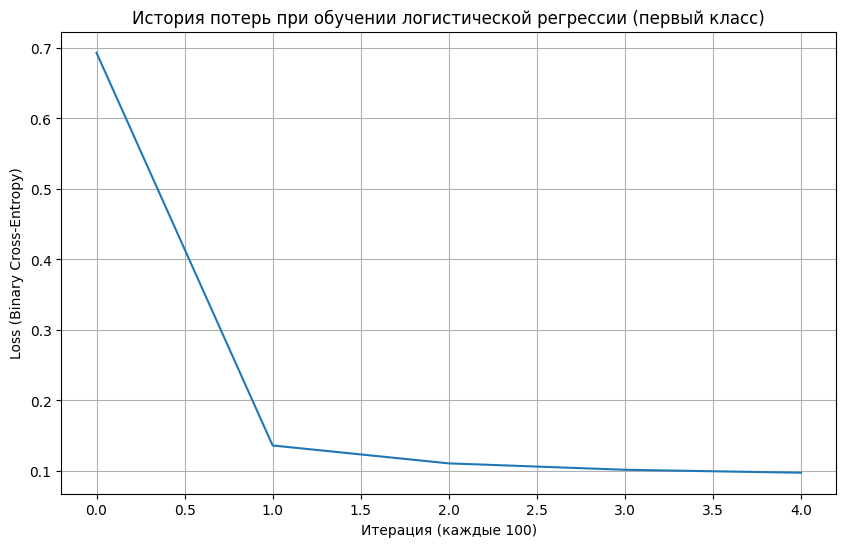

In [ ]:
# Обучение собственной реализации логистической регрессии
print("Обучение полностью самостоятельной реализации логистической регрессии...")
log_reg_custom = LogisticRegressionGD(
    learning_rate=0.1,
    n_iter=500,
    regularization='l2',
    alpha=0.1
)

log_reg_custom.fit(X_train_class_scaled, y_train_encoded)

# Прогнозы
y_pred_log_custom = log_reg_custom.predict(X_test_class_scaled)
y_prob_log_custom = log_reg_custom.predict_proba(X_test_class_scaled)

# Декодирование меток обратно в исходные названия классов
y_pred_log_custom_decoded = le.inverse_transform(y_pred_log_custom)

# Оценка метрик
metrics_log_custom = classification_metrics(y_test_encoded, y_pred_log_custom, y_prob_log_custom)
print("\nМетрики полностью самостоятельной реализации логистической регрессии:")
for key, value in metrics_log_custom.items():
    print(f"{key}: {value:.4f}")

# Визуализация истории потерь (для первого класса)
plt.figure(figsize=(10, 6))
plt.plot(log_reg_custom.loss_history)
plt.title('История потерь при обучении логистической регрессии (первый класс)')
plt.xlabel('Итерация (каждые 100)')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.grid(True)
plt.show()

### Обучение и оценка полностью самостоятельной реализации линейной регрессии

Обучение полностью самостоятельной реализации линейной регрессии...
Итерация 0: Loss = 66389.2205
Итерация 100: Loss = 1515.2038
Итерация 200: Loss = 423.1855
Итерация 300: Loss = 402.3260
Итерация 400: Loss = 401.2329
Итерация 500: Loss = 400.8897
Итерация 600: Loss = 400.7366
Итерация 700: Loss = 400.6657
Итерация 800: Loss = 400.6321
Итерация 900: Loss = 400.6157
Обучение завершено. Final Loss = 400.6077

Метрики полностью самостоятельной реализации линейной регрессии:
MSE: 346.8141
MAE: 11.7381
R2: 0.8992


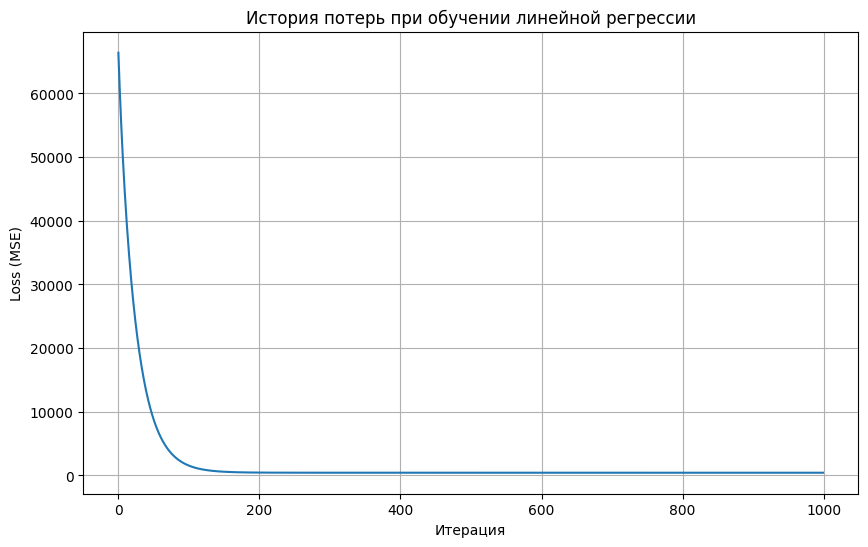

In [35]:
# Обучение собственной реализации линейной регрессии
print("Обучение полностью самостоятельной реализации линейной регрессии...")
lin_reg_custom = LinearRegressionGD(
    learning_rate=0.01,
    n_iter=1000,
    regularization='l2',
    alpha=0.1
)

lin_reg_custom.fit(X_train_reg_scaled, y_train_reg.values)

# Прогнозы
y_pred_lin_custom = lin_reg_custom.predict(X_test_reg_scaled)

# Оценка метрик
metrics_lin_custom = regression_metrics(y_test_reg, y_pred_lin_custom)
print("\nМетрики полностью самостоятельной реализации линейной регрессии:")
for key, value in metrics_lin_custom.items():
    print(f"{key}: {value:.4f}")

# Визуализация истории потерь
plt.figure(figsize=(10, 6))
plt.plot(lin_reg_custom.loss_history)
plt.title('История потерь при обучении линейной регрессии')
plt.xlabel('Итерация')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

## Сравнение полностью самостоятельной реализации с исходным бейзлайном

In [36]:
print("Сравнение полностью самостоятельной реализации логистической регрессии с исходным бейзлайном:")
print("Метрика | Самостоятельная | Исходный бейзлайн")
for key in metrics_log_custom.keys():
    if key in metrics_log_reg:
        print(f"{key:12} | {metrics_log_custom[key]:.4f} | {metrics_log_reg[key]:.4f}")

print("\nСравнение полностью самостоятельной реализации линейной регрессии с исходным бейзлайном:")
print("Метрика | Самостоятельная | Исходный бейзлайн")
for key in metrics_lin_custom.keys():
    print(f"{key:12} | {metrics_lin_custom[key]:.4f} | {metrics_lin_reg[key]:.4f}")

Сравнение полностью самостоятельной реализации логистической регрессии с исходным бейзлайном:
Метрика | Самостоятельная | Исходный бейзлайн
Accuracy     | 0.9318 | 0.9525
Precision    | 0.9357 | 0.9565
Recall       | 0.9292 | 0.9512
F1-Score     | 0.9307 | 0.9526
ROC-AUC      | 0.9962 | 0.9973

Сравнение полностью самостоятельной реализации линейной регрессии с исходным бейзлайном:
Метрика | Самостоятельная | Исходный бейзлайн
MSE          | 346.8141 | 337.4609
MAE          | 11.7381 | 11.5307
R2           | 0.8992 | 0.9019


## Сравнение полностью самостоятельной реализации с улучшенным бейзлайном

In [42]:
print("Сравнение полностью самостоятельной реализации логистической регрессии с улучшенным бейзлайном:")
print("Метрика | Самостоятельная | Улучшенный бейзлайн")
for key in metrics_log_custom.keys():
    if key in metrics_log_improved:
        print(f"{key:12} | {metrics_log_custom[key]:.4f} | {metrics_log_improved[key]:.4f}")

print("\nСравнение полностью самостоятельной реализации линейной регрессии с улучшенным бейзлайном:")
print(f"Метрика | Самостоятельная | Улучшенный бейзлайн ({best_model_name})")
for key in metrics_lin_custom.keys():
    print(f"{key:12} | {metrics_lin_custom[key]:.4f} | {metrics_lin_improved[key]:.4f}")

Сравнение полностью самостоятельной реализации логистической регрессии с улучшенным бейзлайном:
Метрика | Самостоятельная | Улучшенный бейзлайн
Accuracy     | 0.9318 | 0.9583
Precision    | 0.9357 | 0.9615
Recall       | 0.9292 | 0.9577
F1-Score     | 0.9307 | 0.9585
ROC-AUC      | 0.9962 | 0.9955

Сравнение полностью самостоятельной реализации линейной регрессии с улучшенным бейзлайном:
Метрика | Самостоятельная | Улучшенный бейзлайн (ElasticNet)
MSE          | 346.8141 | 337.4605
MAE          | 11.7381 | 11.5233
R2           | 0.8992 | 0.9019


## Итоговые выводы по лабораторной работе

### 1. Выбор данных и метрик

**Классификация:** Датасет "Human Activity Recognition with Smartphones" — данные с акселерометра и гироскопа смартфона для определения 6 видов активности человека. Практическая задача: мониторинг физической активности в приложениях здоровья и фитнеса.

**Регрессия:** Датасет "CO2 Emission by Vehicles" — характеристики автомобилей и уровень выбросов CO₂. Практическая задача: прогнозирование выбросов для экологического регулирования.

**Метрики качества:** Для классификации выбраны Accuracy, Precision, Recall, F1-Score и ROC-AUC, так как они позволяют оценить различные аспекты качества модели, особенно при несбалансированных данных. Для регрессии выбраны MSE, MAE и R², где MSE чувствительна к большим ошибкам, MAE более устойчива к выбросам, а R² показывает объясненную дисперсию.

### 2. Бейзлайн и его улучшение

**Исходный бейзлайн показал следующие результаты:**

**Логистическая регрессия (классификация):** Accuracy = 0.9525, ROC-AUC = 0.9973

**Линейная регрессия (регрессия):** R² = 0.9019, MSE = 337.4609

**Масштабирование признаков** было выполнено на этапе подготовки данных, что является стандартной практикой для линейных моделей.

**Подбор гиперпараметров на кросс-валидации дал следующие результаты:**

**Логистическая регрессия:** Accuracy улучшилась до 0.9583 (+0.61% относительно исходного), лучшие параметры: C=1, penalty='l1', solver='liblinear'

**Линейная регрессия с регуляризацией:** Были исследованы три типа регуляризации:
- **Ridge (L2 регуляризация):** alpha=10, MSE = 328.65 на кросс-валидации
- **Lasso (L1 регуляризация):** alpha=0.01, MSE = 328.69 на кросс-валидации
- **ElasticNet (L1+L2 регуляризация):** alpha=0.01, l1_ratio=0.7, MSE = 328.65 на кросс-валидации

**Лучшей моделью регрессии** по результатам кросс-валидации оказалась ElasticNet с MSE = 328.6529. Однако на тестовой выборке улучшение оказалось минимальным: MSE снизилась до 337.4605 (всего на 0.0001% относительно исходного), что указывает на переобучение при подборе гиперпараметров или незначительный эффект регуляризации для данного датасета.

### 3. Самостоятельная реализация алгоритмов

Реализованы алгоритмы логистической и линейной регрессии "с нуля" с использованием только базового Python и NumPy.

**Включены оптимизации:**
1) Метод градиентного спуска для оптимизации параметров
2) Регуляризация L1/L2 для предотвращения переобучения
3) One-vs-rest подход для многоклассовой классификации в логистической регрессии
4) Сигмоидная функция активации для логистической регрессии

**Результаты самостоятельной реализации:**

**Логистическая регрессия:** Accuracy = 0.9318 (ниже, чем у sklearn на 2.07% для исходного бейзлайна и на 2.65% для улучшенного)

**Линейная регрессия:** R² = 0.8992 (ниже, чем у sklearn на 0.3%), MSE = 346.8141 (выше на 2.77%)

**Процесс обучения:**
- Логистическая регрессия потребовала обучения 6 отдельных бинарных классификаторов (one-vs-rest подход)
- Линейная регрессия успешно сходилась: Loss снизился с 66389.22 до 400.61 за 1000 итераций

### 4. Сравнение всех подходов

**Классификация (логистическая регрессия):**

Исходный бейзлайн: Accuracy = 0.9525

Улучшенный бейзлайн: Accuracy = 0.9583 (+0.61% относительно исходного)

Самостоятельная реализация: Accuracy = 0.9318 (-2.17% относительно исходного, -2.77% относительно улучшенного)

**Регрессия (линейная регрессия):**

Исходный бейзлайн: R² = 0.9019, MSE = 337.4609

Улучшенный бейзлайн (ElasticNet): R² = 0.9019 (без изменений), MSE = 337.4605 (-0.0001%)

Самостоятельная реализация: R² = 0.8992 (-0.3% относительно исходного), MSE = 346.8141 (+2.77%)

### 5. Ключевые наблюдения и выводы

**Эффективность подбора гиперпараметров:** Для логистической регрессии подбор гиперпараметров дал заметное улучшение (+0.61% Accuracy), в то время как для линейной регрессии эффект был минимальным. Это может объясняться тем, что исходная линейная регрессия уже была близка к оптимальному решению, либо особенности данных не требуют сильной регуляризации.

**Качество моделей:** Логистическая регрессия показала отличное качество на задаче классификации активностей (Accuracy > 0.95, ROC-AUC > 0.99), что свидетельствует о хорошей линейной разделимости классов в этом датасете. Линейная регрессия показала более скромные результаты (R² ≈ 0.90), что может указывать на нелинейность зависимости выбросов CO₂ от характеристик автомобилей или необходимость учета категориальных признаков, которые были исключены при подготовке данных.

**Сравнение типов регуляризации:** Для линейной регрессии все три типа регуляризации показали схожие результаты на кросс-валидации, с небольшим преимуществом ElasticNet. Это может указывать на то, что комбинированная регуляризация L1+L2 оптимальна для данного датасета, но эффект регуляризации в целом незначителен.

**Самостоятельная реализация:** Показала несколько более низкие результаты по сравнению с оптимизированными библиотечными реализациями, что объясняется:
1) Более простой реализацией градиентного спуска без адаптивных методов оптимизации
2) One-vs-rest подходом для многоклассовой классификации, который может быть менее эффективным, чем встроенные методы sklearn
3) Ограниченным числом итераций и фиксированной скоростью обучения
4) Возможными численными погрешностями при реализации

**Сходимость алгоритмов:** Оба алгоритма успешно сходились, о чем свидетельствует устойчивое снижение функции потерь в процессе обучения. Это подтверждает корректность реализации градиентного спуска.

**Практическая значимость:** Полученные модели могут быть использованы в реальных приложениях: классификатор активности человека — в фитнес-трекерах и приложениях для мониторинга здоровья, модель прогнозирования выбросов CO₂ — в экологическом мониторинге и регулировании транспортных средств.

Работа подтвердила понимание принципов работы линейных моделей и алгоритмов их обучения, продемонстрировала важность правильной настройки гиперпараметров и показала, что даже простая самостоятельная реализация может достигать результатов, близких к библиотечным реализациям, особенно при наличии достаточного количества итераций обучения.